In [14]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
PKLs = []
PKL_titles = []
DIR = "./"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR + file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

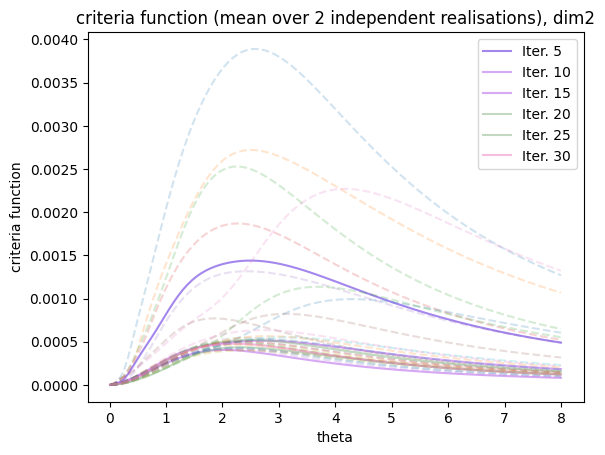

In [15]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
idx = 1
mpm1 = PKLs[idx]['res'][0].shape[2]*(PKLs[idx]['res'][0].shape[3]-1)
for j in range(1, PKLs[idx]['res'][5].shape[1]):
    plt.plot(GRID_ESJD, PKLs[idx]['res'][5].mean(axis=0)[j,:], label=f"Iter. {str(j)}", alpha=0.5 if j%5==0 else 0.2, color=color_set[j//10], linestyle="solid" if j%5==0 else "--")
plt.legend()
plt.title(f"criteria function (mean over {PKLs[idx]['res'][5].shape[0]} independent realisations), dim{PKLs[idx]['res'][0].shape[-1]}")
plt.ylabel("criteria function")
plt.xlabel("theta")
plt.savefig(DIR+f"{PKL_titles[idx]}criteria_function.png")


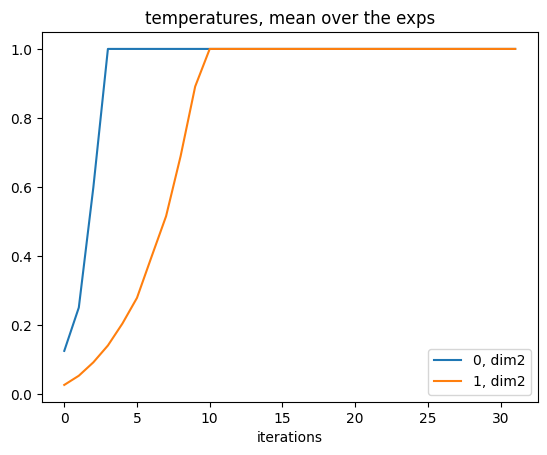

In [16]:
for idx in range(n):
    plt.plot(np.mean(PKLs[idx]['res'][6], axis=0), label=f'{idx}, dim{PKLs[idx]['res'][0].shape[-1]}')
plt.title('temperatures, mean over the exps')
plt.xlabel('iterations')
plt.legend()

In [17]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'gamma' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)

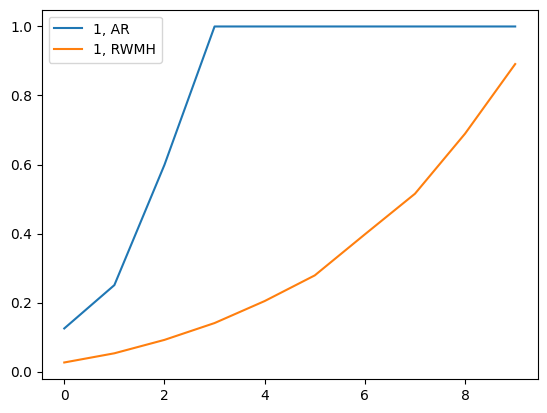

In [18]:
plt.plot(np.mean([np.mean(PKLs[idx]['res'][6], axis=0) for idx in list_idx_ar], axis=0)[:10], label=f'{idx}, AR')
plt.plot(np.mean([np.mean(PKLs[idx]['res'][6], axis=0) for idx in list_idx_rwmh], axis=0)[:10], label=f'{idx}, RWMH')
plt.legend()

In [19]:
dic_test = {}
for idx in range(len(PKLs)):
    if jnp.sum(PKLs[idx]['res'][6])==0:
        dic_test[float(PKLs[idx]['config']['tau'])] = dic_test.get(float(PKLs[idx]['config']['tau']), 0)+1

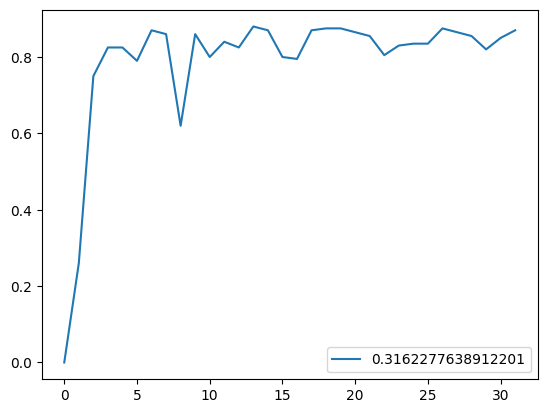

In [20]:
for idx in list_idx_ar:
    plt.plot(np.mean(PKLs[idx]['res'][2], axis=0), label=f'{PKLs[idx]['config']['tau']}')
plt.legend()

In [21]:
rhos = np.zeros((len(list_idx_ar), 26, 1))
taus = np.zeros(len(list_idx_ar))
for _idx, idx in enumerate(list_idx_ar):
    rho = np.mean(PKLs[idx]['res'][2], axis=0)
    tau = PKLs[idx]['config']['tau']
    rhos[_idx] = rho
    taus[_idx] = tau
    
for it in range(1, rhos.shape[1]):
    plt.plot(taus,np.sqrt(1-rhos[:,it,-1]**2), label=f'iter {it}')
plt.legend()

ValueError: could not broadcast input array from shape (32,1) into shape (26,1)

In [22]:
taus

array([0.])

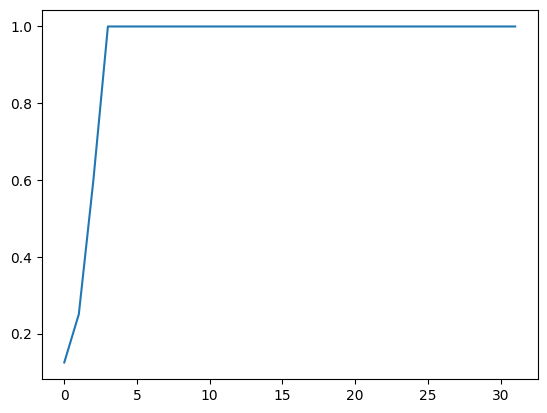

In [23]:
for idx in list_idx_ar:
    plt.plot(np.mean(PKLs[idx]['res'][6], axis=0), label=f'{idx}, dim{PKLs[idx]['res'][0].shape[-1]}')

exp_rwmh_vs_ar_gaussian_to_gaussian.py_02022025152042.pkl


/tmp/ipykernel_20647/3805563788.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


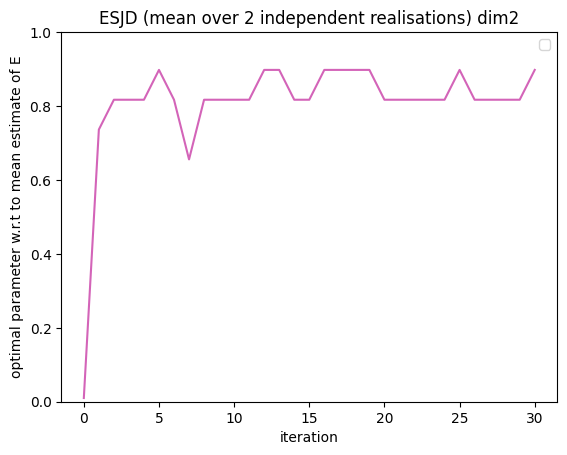

In [24]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
color_set
idx = 0
print(PKL_titles[idx])
mpm1 = PKLs[idx]['res'][0].shape[2]*(PKLs[idx]['res'][0].shape[3]-1)
max=13
plt.plot([GRID_ESJD[:max][np.argmax(PKLs[idx]['res'][5].mean(axis=0)[j,:max])] for j in range(1, PKLs[idx]['res'][5].shape[1])], alpha=0.9, color=color_set[j//10], linestyle="solid")
plt.ylim(0.0, 1.)
plt.legend()
plt.title(f"ESJD (mean over {PKLs[idx]['res'][5].shape[0]} independent realisations) dim{PKLs[idx]['res'][0].shape[-1]}")
plt.ylabel("optimal parameter w.r.t to mean estimate of E")
plt.xlabel("iteration")
plt.savefig(DIR+f"{PKL_titles[idx]}optimal_parameter_wrt_to_mean_estimate_of_E.png")

In [29]:
PKLs[idx]['res'][5][0,:,:13]

Array([[-7.9297944e+05, -7.9297944e+05, -7.9297944e+05, -7.9297944e+05,
        -7.9297944e+05, -7.9297944e+05, -7.9297944e+05, -7.9297944e+05,
        -7.9297944e+05, -7.9297944e+05, -7.9297944e+05, -7.9297944e+05,
        -7.9297944e+05],
       [ 1.7419678e-01,  1.7851619e-01,  1.8209168e-01,  1.8485267e-01,
         1.8665376e-01,  1.8724109e-01,  1.8619442e-01,  1.8282363e-01,
         1.7597687e-01,  1.6366330e-01,  1.4224610e-01,  1.0447023e-01,
         3.2462534e-02],
       [ 5.8761351e-02,  6.1559118e-02,  6.4315103e-02,  6.7065120e-02,
         6.9835603e-02,  7.2637379e-02,  7.5451009e-02,  7.8191824e-02,
         8.0622815e-02,  8.2117520e-02,  8.0923334e-02,  7.1367256e-02,
         2.8776342e-02],
       [ 1.6055023e-02,  1.7154256e-02,  1.8247990e-02,  1.9359510e-02,
         2.0513162e-02,  2.1735221e-02,  2.3054387e-02,  2.4500562e-02,
         2.6097314e-02,  2.7830079e-02,  2.9507361e-02,  2.9993664e-02,
         1.8872375e-02],
       [ 1.5524624e-02,  1.6591746e-

In [11]:
GRID_ESJD[:13]

Array([0.01      , 0.09070707, 0.17141414, 0.2521212 , 0.33282828,
       0.41353536, 0.49424243, 0.57494944, 0.6556566 , 0.73636365,
       0.81707066, 0.8977778 , 0.97848487], dtype=float32)

In [12]:
idx = 2
for t in range(PKLs[idx]['res'][5].shape[-1]):
    plt.plot(PKLs[idx]['res'][5][..., t][...,1:].mean(axis=0))
plt.xlabel("iter")
plt.ylabel("eval. of criteria function")
plt.title(r"criteria function for different \theta")

IndexError: list index out of range

In [25]:
PKLs[idx]['res'][5].shape[-1]

100

Text(0.5, 1.0, 'ESS')

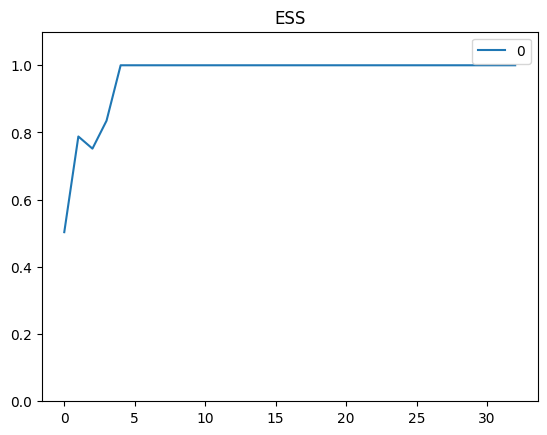

In [25]:
idx=0
weights = np.exp(PKLs[idx]['res'][1][:,:,].reshape((*PKLs[idx]['res'][1].shape[:2], -1)))
num_particles = weights.shape[-1]
plt.ylim((0, 1.1))
plt.plot(np.mean(1/np.sum(np.square(weights), axis=-1).T/num_particles, axis=-1), label=idx)
plt.legend()
plt.title("ESS")

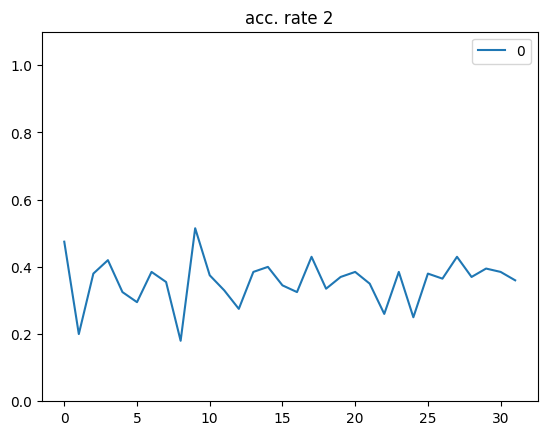

In [26]:
idx=0
plt.plot(PKLs[idx]['res'][3][0].mean(axis=[1, 2]), label=idx)
plt.ylim((0, 1.1))
plt.title(f"acc. rate {PKLs[idx]['res'][0].shape[-1]}")
plt.legend()
plt.savefig(DIR+f"{PKL_titles[idx]}acc_rate.png")

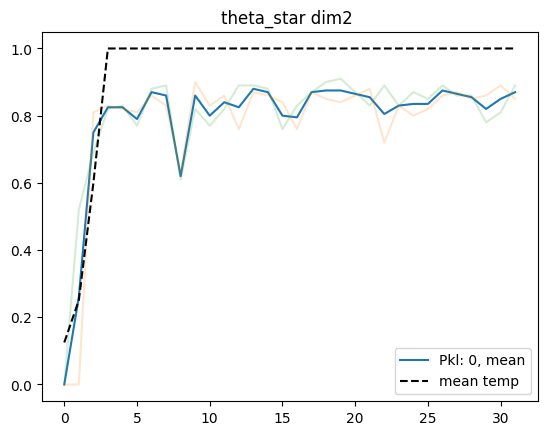

In [27]:
idx=0
plt.plot(PKLs[idx]['res'][2][...,0].mean(axis=0), label=f"Pkl: {idx}, mean")
plt.plot(PKLs[idx]['res'][2][...,0].T, alpha=0.2)
plt.plot(np.mean(PKLs[idx]['res'][6], axis=0), label=f"mean temp", color="black", linestyle="--")
plt.title(f"theta_star dim{PKLs[idx]['res'][0].shape[-1]} ")
plt.savefig(f"{PKL_titles[idx]}theta_star.png")
plt.legend()

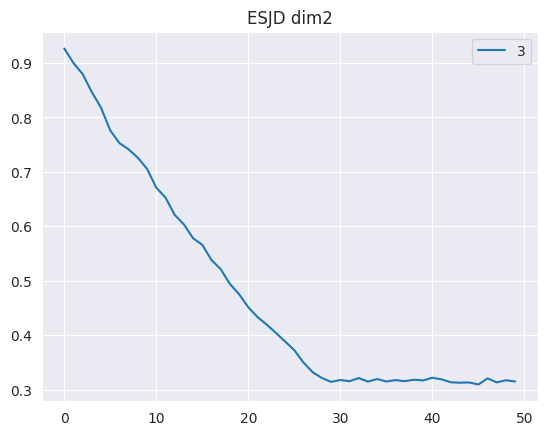

In [75]:
idx=3
plt.plot(np.sum(np.square(np.diff(PKLs[idx]['res'][0], axis=-2, n=1)), axis=-1).mean((0, 2, 3))[1:], label=idx)
plt.title(f"ESJD dim{PKLs[idx]['res'][0].shape[-1]}")
plt.legend()

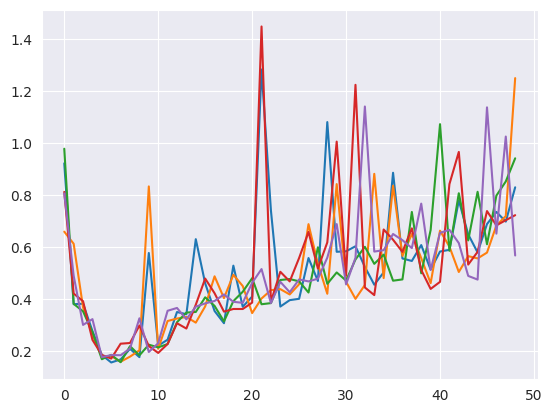

In [95]:
import jax
import jax.numpy as jnp
idx=0
is_weights = jnp.exp(PKLs[idx]['res'][4])
is_weights = is_weights.reshape(is_weights.shape[:2] + (-1,))
is_weights_shape = is_weights.shape
var_over_mean_sq = jnp.vectorize(lambda s: jnp.var(s)/jnp.mean(s)**2, signature="(n)->()")(is_weights)
plt.plot(var_over_mean_sq.T[1:])

In [37]:
PKLs[1]['res'][6]

IndexError: list index out of range